# 01 — Data Exploration & Chunk Quality Analysis

This notebook validates the output of the ingestion pipeline (Week 1).
Use it to:
- Inspect the raw chunks generated by `processor.py`
- Detect anomalies (empty chunks, encoding issues, noise)
- Visualise chunk length distributions per company
- Spot-check text quality before generating embeddings

**Run this before `embeddings.py`** to make sure your data is clean.

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PROCESSED_DIR = Path('../data/processed')
COMPANIES = ['tesla', 'apple', 'microsoft']
COLORS = {'tesla': '#E31937', 'apple': '#555555', 'microsoft': '#00A4EF'}

## 1. Load all chunks into a DataFrame

In [ ]:
all_chunks = []

for company in COMPANIES:
    path = PROCESSED_DIR / f'{company}_chunks.json'
    if not path.exists():
        print(f'Missing: {path}')
        continue
    chunks = json.loads(path.read_text(encoding='utf-8'))
    all_chunks.extend(chunks)
    print(f'  {company:12s}: {len(chunks):,} chunks loaded')

df = pd.DataFrame(all_chunks)
print(f'\nTotal chunks: {len(df):,}')
df.head(3)

  tesla       : 116 chunks loaded
  apple       : 57 chunks loaded
  microsoft   : 85 chunks loaded

Total chunks: 258


,chunk_id,text,start_page,end_page,word_count,company,source
0,0,ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) ...,1,2,500,tesla,tesla_10k.htm
1,1,"completed second fiscal quarter, was $ 892.93 ...",1,3,500,tesla,tesla_10k.htm
2,2,SEC”). The discussion of such risks is not an ...,3,4,500,tesla,tesla_10k.htm


## 2. Basic statistics

In [4]:
# Add character count column
df['char_count'] = df['text'].str.len()

stats = df.groupby('company').agg(
    total_chunks   = ('chunk_id',   'count'),
    avg_words      = ('word_count', 'mean'),
    min_words      = ('word_count', 'min'),
    max_words      = ('word_count', 'max'),
    avg_chars      = ('char_count', 'mean'),
    pages_covered  = ('end_page',   'max'),
).round(1)

print(stats.to_string())

           total_chunks  avg_words  min_words  max_words  avg_chars  pages_covered
company                                                                           
apple                57      495.8        263        500     3341.3             58
microsoft            85      494.9         63        500     3362.6             86
tesla               116      498.9        367        500     3300.0            116


## 3. Chunk length distribution

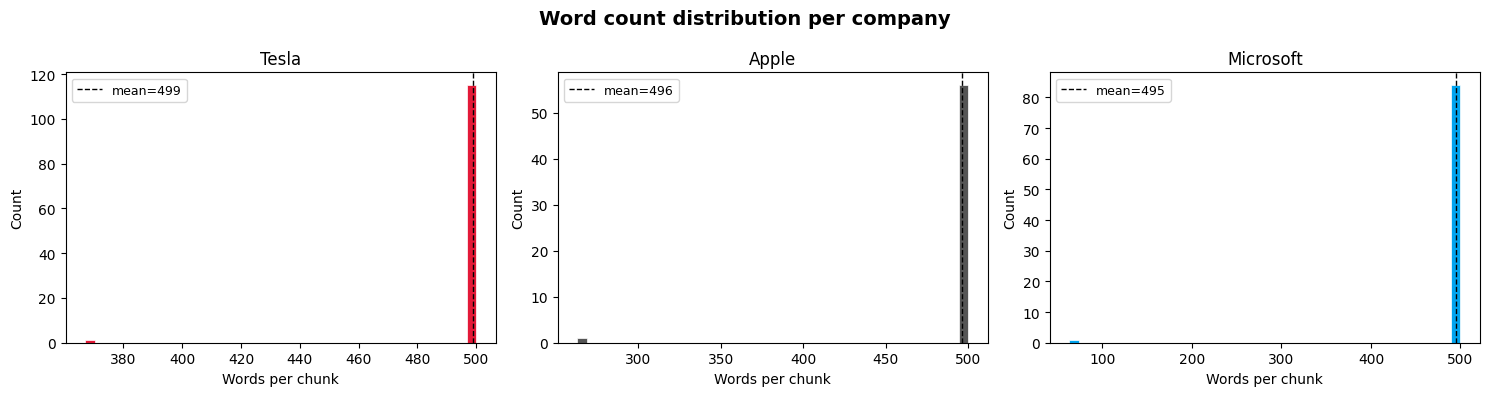

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Word count distribution per company', fontsize=14, fontweight='bold')

for ax, company in zip(axes, COMPANIES):
    subset = df[df['company'] == company]['word_count']
    ax.hist(subset, bins=40, color=COLORS[company], edgecolor='white', linewidth=0.5)
    ax.set_title(company.capitalize())
    ax.set_xlabel('Words per chunk')
    ax.set_ylabel('Count')
    ax.axvline(subset.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={subset.mean():.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 4. Anomaly detection

In [ ]:
# --- Very short chunks (likely noise or parsing errors) ---
short = df[df['word_count'] < 60]
print(f'Chunks with < 60 words: {len(short)} ({len(short)/len(df)*100:.1f}%)')
if not short.empty:
    print('Sample short chunks:')
    for _, row in short.head(3).iterrows():
        print(f'  [{row["company"]} | p{row["start_page"]}] "{row["text"][:120]}"')

⚠️  Chunks with < 60 words: 0 (0.0%)


In [ ]:
# --- Chunks with suspicious repetition (table noise) ---
df['unique_word_ratio'] = df['text'].apply(
    lambda t: len(set(t.split())) / max(len(t.split()), 1)
)
repetitive = df[df['unique_word_ratio'] < 0.3]
print(f'Potentially repetitive chunks: {len(repetitive)}')
if not repetitive.empty:
    sample = repetitive.sample(min(2, len(repetitive)))
    for _, row in sample.iterrows():
        print(f'  [{row["company"]}] ratio={row["unique_word_ratio"]:.2f} | "{row["text"][:120]}"')

⚠️  Potentially repetitive chunks: 4
  [apple] ratio=0.25 | "Rate Notes due 2021, 1.300% Notes due 2018, 1.700% Notes due 2019, 2.250% Notes due 2021, 2.850% Notes due 2023, 3.250% "
  [tesla] ratio=0.25 | "Form 10-K will be included in our 2026 Proxy Statement and is incorporated herein by reference. The information required"


## 5. Spot-check: random samples per company

In [8]:
for company in COMPANIES:
    sample = df[df['company'] == company].sample(1).iloc[0]
    print(f'\n{'─'*60}')
    print(f'  {company.upper()}  |  pages {sample["start_page"]}–{sample["end_page"]}  |  {sample["word_count"]} words')
    print(f'{'─'*60}')
    print(sample['text'][:600])
    print('...')


────────────────────────────────────────────────────────────
  TESLA  |  pages 23–24  |  500 words
────────────────────────────────────────────────────────────
we cannot or do not maintain operations at a scope that is commensurate with such conditions or are later required to or choose to suspend such operations again, our business, prospects, financial condition and operating results may be harmed. Upon launching our Robotaxi service in June 2025, we also entered into the autonomous ride-hailing service market, and have plans to mass produce Cybercab, a purpose-built Robotaxi product. As we seek to expand the scope and geographical footprint of this business, our success will be dependent upon various factors, including the acceptance and adoption 
...

────────────────────────────────────────────────────────────
  APPLE  |  pages 3–5  |  500 words
────────────────────────────────────────────────────────────
as third-party cellula r network carriers and other resellers, for the sale